# Detección de anomalias usando Autoencoders

Referencia [link](https://keras.io/examples/timeseries/timeseries_anomaly_detection/)

In [1]:
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers

from matplotlib import pyplot as plt

2026-01-13 18:25:58.263514: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768350358.283092  200171 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768350358.289395  200171 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768350358.304351  200171 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768350358.304377  200171 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768350358.304379  200171 computation_placer.cc:177] computation placer alr

## Datos

Usaremos el conjunto de datos [Numenta Anomaly Benchmark (NAB)](https://www.kaggle.com/boltzmannbrain/nab). Este proporciona series de tiempo artificiales que contienen períodos anómalos de comportamiento etiquetados. Los datos están ordenados, tienen marcas de tiempo y son métricas de un solo valor.

Usaremos el archivo `art_daily_small_noise.csv` para el entrenamiento y el archivo `art_daily_jumpsup.csv` para las pruebas. La simplicidad de este conjunto de datos nos permite demostrar la detección de anomalías de manera efectiva.



In [2]:
master_url_root = "https://raw.githubusercontent.com/numenta/NAB/master/data/"

df_small_noise_url_suffix = "artificialNoAnomaly/art_daily_small_noise.csv"
df_small_noise_url = master_url_root + df_small_noise_url_suffix
df_small_noise = pd.read_csv(
    df_small_noise_url, parse_dates=True, index_col="timestamp"
)

df_daily_jumpsup_url_suffix = "artificialWithAnomaly/art_daily_jumpsup.csv"
df_daily_jumpsup_url = master_url_root + df_daily_jumpsup_url_suffix
df_daily_jumpsup = pd.read_csv(
    df_daily_jumpsup_url, parse_dates=True, index_col="timestamp"
)

In [3]:
print(df_small_noise.head())

print(df_daily_jumpsup.head())

                         value
timestamp                     
2014-04-01 00:00:00  18.324919
2014-04-01 00:05:00  21.970327
2014-04-01 00:10:00  18.624806
2014-04-01 00:15:00  21.953684
2014-04-01 00:20:00  21.909120
                         value
timestamp                     
2014-04-01 00:00:00  19.761252
2014-04-01 00:05:00  20.500833
2014-04-01 00:10:00  19.961641
2014-04-01 00:15:00  21.490266
2014-04-01 00:20:00  20.187739


In [4]:
df_daily_jumpsup

,value
timestamp,
2014-04-01 00:00:00,19.761252
2014-04-01 00:05:00,20.500833
2014-04-01 00:10:00,19.961641
2014-04-01 00:15:00,21.490266
2014-04-01 00:20:00,20.187739
...,...
2014-04-14 23:35:00,18.074649
2014-04-14 23:40:00,21.002014
2014-04-14 23:45:00,20.566713


## Visualización de los datos
### Series sin anomalías

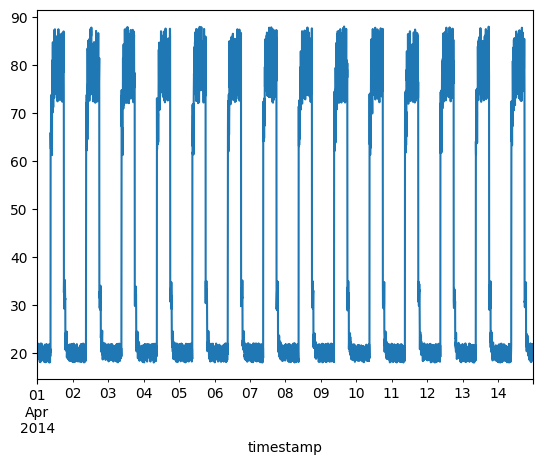

In [5]:
fig, ax = plt.subplots()
df_small_noise.plot(legend=False, ax=ax)
plt.show()

### Series con anomalías

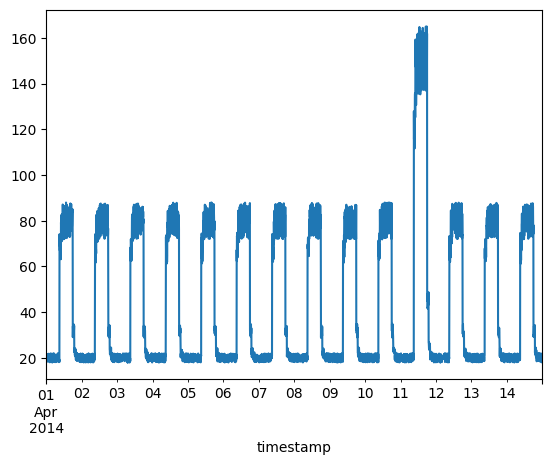

In [6]:
fig, ax = plt.subplots()
df_daily_jumpsup.plot(legend=False, ax=ax)
plt.show()

## Preprocesado

Obtenemos los valores del archivo de datos de la serie de tiempo de entrenamiento y normalizamos los datos de `value`. Tenemos un `value` cada 5 minutos durante 14 días.

* 24 * 60 / 5 = **288 pasos de tiempo por día**
* 288 * 14 = **4032 puntos de datos** en total"


In [7]:
training_mean = df_small_noise.mean()
training_std = df_small_noise.std()
df_training_value = (df_small_noise - training_mean) / training_std
print("Número de ejemplos de entrenamiento:", len(df_training_value))

Número de ejemplos de entrenamiento: 4032


### Creación de secuancias

In [8]:
TIME_STEPS = 288


# Generated training sequences for use in the model.
def create_sequences(values, time_steps=TIME_STEPS):
    output = []
    for i in range(len(values) - time_steps + 1):
        output.append(values[i : (i + time_steps)])
    return np.stack(output)


x_train = create_sequences(df_training_value.values)
print("Training input shape: ", x_train.shape)

Training input shape:  (3745, 288, 1)


## Construcción del modelo

In [ ]:
ht = [1,0,5,2]

[
[1,0,5,2]
[1,0,5,2]
[1,0,5,2]
[1,0,5,2]
[1,0,5,2]
]

minimizar $||x - \hat{x}||$


$\hat{x} = f(x)$

In [9]:
# LSTM Autoencoder
model = tf.keras.Sequential([
    # Encoder
    layers.Input(shape=(x_train.shape[1], x_train.shape[2])),
    layers.LSTM(64, activation='tanh', return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(32, activation='tanh', return_sequences=True),
    
    # Encaje
    layers.Dropout(0.2),
    layers.LSTM(16, activation='tanh', return_sequences=False), 
    layers.RepeatVector(x_train.shape[1]),
    
    # Decoder
    layers.LSTM(32, activation='tanh', return_sequences=True),
    layers.Dropout(0.2),
    layers.LSTM(64, activation='tanh', return_sequences=True),
    layers.TimeDistributed(layers.Dense(x_train.shape[2]))
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss="mse")
model.summary()

I0000 00:00:1768350362.872738  200171 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13851 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Ti SUPER, pci bus id: 0000:07:00.0, compute capability: 8.9


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 288, 64)        │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 288, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 288, 32)        │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 288, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 288, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 288, 32)        │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 288, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 288, 64)        │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 288, 1)         │            65 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 63,617 (248.50 KB)

 Trainable params: 63,617 (248.50 KB)

 Non-trainable params: 0 (0.00 B)

## Entrenamiento

In [10]:
history = model.fit(
    x_train,
    x_train,
    epochs=100,
    batch_size=128,
    validation_split=0.1,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=5, mode="min")
    ],
)

Epoch 1/100


I0000 00:00:1768350372.718700  200329 cuda_dnn.cc:529] Loaded cuDNN version 91001


27/27 ━━━━━━━━━━━━━━━━━━━━ 14s 160ms/step - loss: 0.9981 - val_loss: 1.0077
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - loss: 0.9960 - val_loss: 1.0036
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 0.9874 - val_loss: 0.9933
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 0.9648 - val_loss: 0.9832
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 0.9504 - val_loss: 0.9605
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.9275 - val_loss: 0.9240
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.8972 - val_loss: 0.9059
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.8770 - val_loss: 0.8913
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - loss: 0.8719 - val_loss: 0.8804
Epoch 10/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0.8598 - val_loss: 0.8752
Epoch 11/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 0.8525 - val_loss: 0.8620
Epoch 12/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - loss: 0

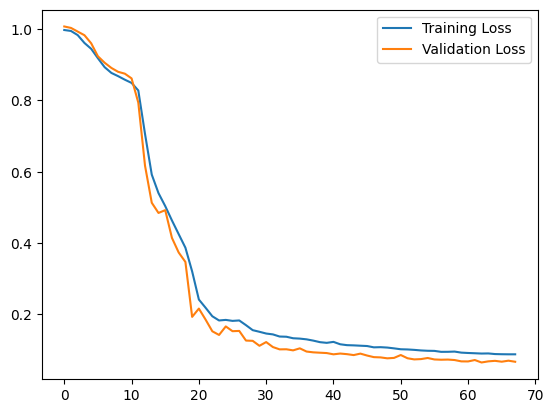

In [11]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.legend()
plt.show()

## Detectando anomalías

Detectaremos anomalías determinando qué tan bien nuestro modelo puede reconstruir los datos de entrada.

1. Calcular la pérdida MAE en las muestras de entrenamiento.
2. Encontrar el valor máximo de la pérdida MAE. Este es el peor desempeño de nuestro modelo al intentar reconstruir una muestra. Usaremos este valor como el `umbral` para la detección de anomalías.
3. Si la pérdida de reconstrucción para una muestra es mayor que este valor `umbral`, entonces podemos inferir que el modelo está observando un patrón con el que no está familiarizado. Etiquetaremos esta muestra como una `anomalía`.


118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step


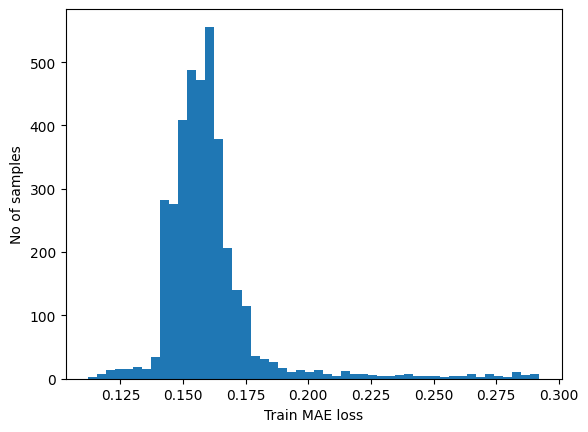

Reconstrucción del umbral de error:  0.2697817182990098


In [19]:
# Obtenemos el MAE.
x_train_pred = model.predict(x_train)
train_mae_loss = np.mean(np.abs(x_train_pred - x_train), axis=1)

plt.hist(train_mae_loss, bins=50)
plt.xlabel("Train MAE loss")
plt.ylabel("No of samples")
plt.show()

threshold = np.quantile(train_mae_loss,0.99) #np.max(train_mae_loss)
print("Reconstrucción del umbral de error: ", threshold)

In [20]:
len(train_mae_loss)

3745

### Comparar reconstrucción

Veamos cómo nuestro modelo ha reconstruido la primera muestra.
Esta corresponde a los **288 pasos de tiempo del día 1** de nuestro conjunto de entrenamiento.



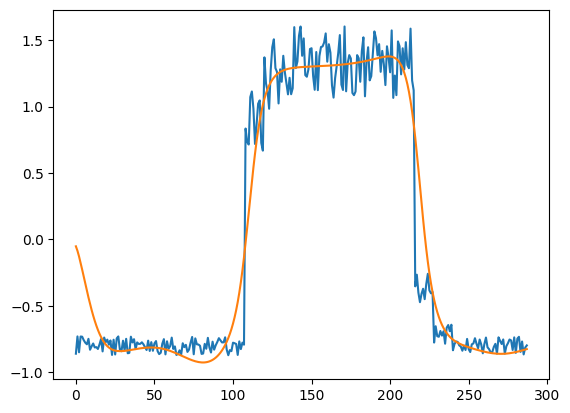

In [21]:
# Checking how the first sequence is learnt
plt.plot(x_train[0])
plt.plot(x_train_pred[0])
plt.show()

### Preparación de los datos test

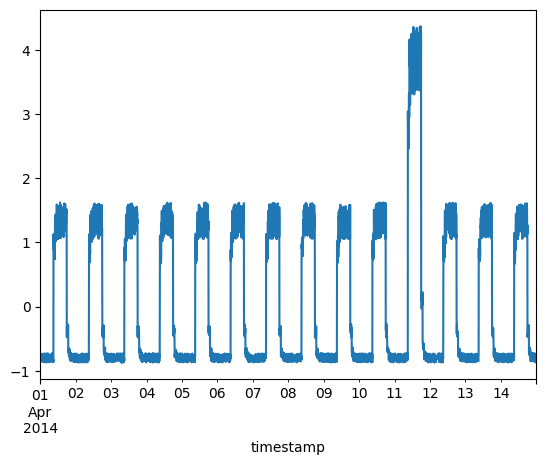

Test input shape:  (3745, 288, 1)


In [22]:

df_test_value = (df_daily_jumpsup - training_mean) / training_std
fig, ax = plt.subplots()
df_test_value.plot(legend=False, ax=ax)
plt.show()

x_test = create_sequences(df_test_value.values)
print("Test input shape: ", x_test.shape)



118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step


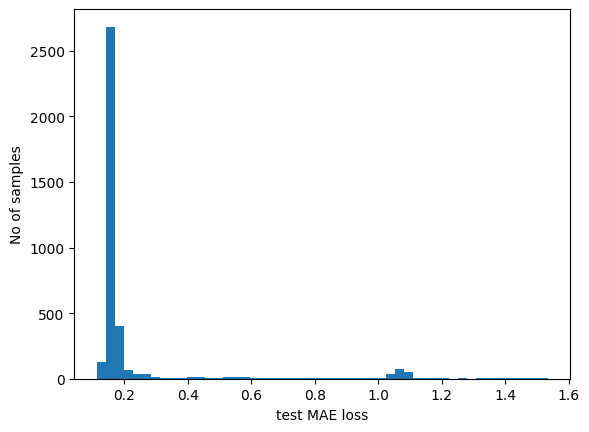

Number of anomaly samples:  407
Indices of anomaly samples:  (array([ 202,  203,  204,  489,  490,  776,  777,  778,  779, 1067, 1068,
       1354, 1355, 1356, 1641, 1642, 1643, 1927, 1928, 1929, 2216, 2217,
       2218, 2506, 2507, 2508, 2712, 2713, 2714, 2715, 2716, 2717, 2718,
       2719, 2720, 2721, 2722, 2723, 2724, 2725, 2726, 2727, 2728, 2729,
       2730, 2731, 2732, 2733, 2734, 2735, 2736, 2737, 2738, 2739, 2740,
       2741, 2742, 2743, 2744, 2745, 2746, 2747, 2748, 2749, 2750, 2751,
       2752, 2753, 2754, 2755, 2756, 2757, 2758, 2759, 2760, 2761, 2762,
       2763, 2764, 2765, 2766, 2767, 2768, 2769, 2770, 2771, 2772, 2773,
       2774, 2775, 2776, 2777, 2778, 2779, 2780, 2781, 2782, 2783, 2784,
       2785, 2786, 2787, 2788, 2789, 2790, 2791, 2792, 2793, 2794, 2795,
       2796, 2797, 2798, 2799, 2800, 2801, 2802, 2803, 2804, 2805, 2806,
       2807, 2808, 2809, 2810, 2811, 2812, 2813, 2814, 2815, 2816, 2817,
       2818, 2819, 2820, 2821, 2822, 2823, 2824, 2825, 2826, 2

In [23]:
x_test_pred = model.predict(x_test)
test_mae_loss = np.mean(np.abs(x_test_pred - x_test), axis=1)
test_mae_loss = test_mae_loss.reshape((-1))

plt.hist(test_mae_loss, bins=50)
plt.xlabel("test MAE loss")
plt.ylabel("No of samples")
plt.show()

# Detect all the samples which are anomalies.
anomalies = test_mae_loss > threshold
print("Number of anomaly samples: ", np.sum(anomalies))
print("Indices of anomaly samples: ", np.where(anomalies))


## Plot de anomalías

Ahora ya conocemos las muestras de los datos que son anomalías. Con esto, encontraremos las `timestamps` correspondientes a partir de los datos originales de prueba. Usaremos el siguiente método para hacerlo:

Supongamos que **time_steps = 3** y tenemos **10 valores de entrenamiento**. Nuestro `x_train` se verá así:

* 0, 1, 2
* 1, 2, 3
* 2, 3, 4
* 3, 4, 5
* 4, 5, 6
* 5, 6, 7
* 6, 7, 8
* 7, 8, 9

Excepto los valores iniciales y finales (time_steps - 1), todos los demás aparecerán en `time_steps` muestras distintas. Por lo tanto, si sabemos que las muestras
[(3, 4, 5), (4, 5, 6), (5, 6, 7)]
son anomalías, podemos decir que el punto de dato **5** es una anomalía.



In [24]:
anomalous_data_indices = []
for data_idx in range(TIME_STEPS - 1, len(df_test_value) - TIME_STEPS + 1):
    if np.all(anomalies[data_idx - TIME_STEPS + 1 : data_idx]):
        anomalous_data_indices.append(data_idx)

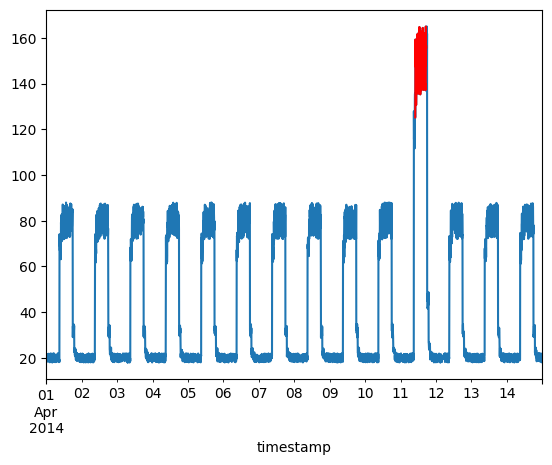

In [25]:
df_subset = df_daily_jumpsup.iloc[anomalous_data_indices]
fig, ax = plt.subplots()
df_daily_jumpsup.plot(legend=False, ax=ax)
df_subset.plot(legend=False, ax=ax, color="r")
plt.show()